# MSCS-634: Advanced Big Data and Data Mining
### Lab 2: Classification Using KNN and RNN Algorithms
**Name:** Samia Zaman

**Dataset:** Wine dataset from `sklearn.datasets` - 178 wine samples described by 13 chemical
properties (alcohol, malic acid, ash, magnesium, flavanoids, proline, etc.), labeled with one of
three cultivar classes.


## Step 1: Load and Prepare the Dataset

The Wine dataset is loaded directly from `sklearn.datasets.load_wine`. It contains 178 samples,
13 numeric features, and 3 target classes (three different wine cultivars). The features are
kept on their original (unscaled) measurement scales, since that is what the radius values used
later for Radius Neighbors are calibrated against.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.rcParams["figure.figsize"] = (8, 5)

wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

df.shape


(178, 14)

**First five rows of the dataset:**

In [2]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


### 1.1 Feature Details

In [3]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


**Notes:** The 13 features live on very different scales - e.g. `proline` ranges roughly from
278 to 1680, while `hue` ranges from about 0.5 to 1.7. This matters for both classifiers, since
larger-scale features (like `proline`) end up dominating the Euclidean distance calculation, and
it's also why the Radius Neighbors radius values used in this lab (350-600) are in the hundreds
rather than single digits.


### 1.2 Class Distribution

In [4]:
class_counts = df["target"].value_counts().sort_index()
class_counts.index = wine.target_names
class_counts


class_0    59
class_1    71
class_2    48
Name: count, dtype: int64

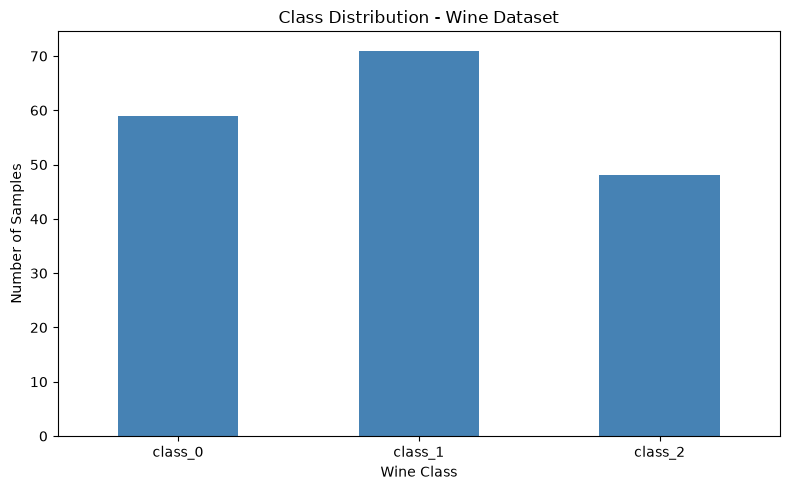

In [5]:
plt.figure()
class_counts.plot(kind="bar", color="steelblue")
plt.xlabel("Wine Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution - Wine Dataset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()


**Insight:** The three classes are reasonably balanced but not identical - 59, 71, and 48
samples respectively - so accuracy is a reasonable metric to track here without needing to
worry about a heavily skewed majority class.


### 1.3 Train/Test Split

In [6]:
X = df[wine.feature_names]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")


Training set: 142 samples
Test set: 36 samples


**Notes:** The split is stratified on the target class so the 80/20 split preserves the same
class proportions in both the training and test sets.


## Step 2: Implement K-Nearest Neighbors (KNN)

KNN classifiers are trained for k = 1, 5, 11, 15, and 21, each evaluated on the held-out test
set.


In [7]:
knn_k_values = [1, 5, 11, 15, 21]
knn_results = []

for k in knn_k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    knn_results.append({"k": k, "accuracy": acc})

knn_df = pd.DataFrame(knn_results)
knn_df


,k,accuracy
0,1,0.777778
1,5,0.805556
2,11,0.805556
3,15,0.805556
4,21,0.805556


**Notes:** Accuracy is lowest at k=1 (a single neighbor is noisy and easily thrown off by
mislabeled or borderline points) and improves once k is large enough to vote across several
neighbors, then levels off for k=5 and above.


## Step 3: Implement Radius Neighbors (RNN)

Radius Neighbors classifiers are trained for radius values of 350, 400, 450, 500, 550, and 600,
each evaluated on the held-out test set. These radius values are only meaningful because the
features were kept on their original scale - `proline` alone spans over 1000 units, so a radius
in the hundreds is needed to capture a useful neighborhood.


In [8]:
rnn_radius_values = [350, 400, 450, 500, 550, 600]
rnn_results = []

for r in rnn_radius_values:
    rnn = RadiusNeighborsClassifier(radius=r)
    rnn.fit(X_train, y_train)
    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    rnn_results.append({"radius": r, "accuracy": acc})

rnn_df = pd.DataFrame(rnn_results)
rnn_df


,radius,accuracy
0,350,0.722222
1,400,0.694444
2,450,0.694444
3,500,0.694444
4,550,0.666667
5,600,0.666667


**Notes:** Unlike KNN, RNN accuracy trends downward as the radius grows. A small radius keeps
the neighborhood tight and mostly same-class, while a larger radius starts pulling in points
from neighboring classes, which drags accuracy down.


## Step 4: Visualize and Compare Results

### 4.1 KNN Accuracy Trend

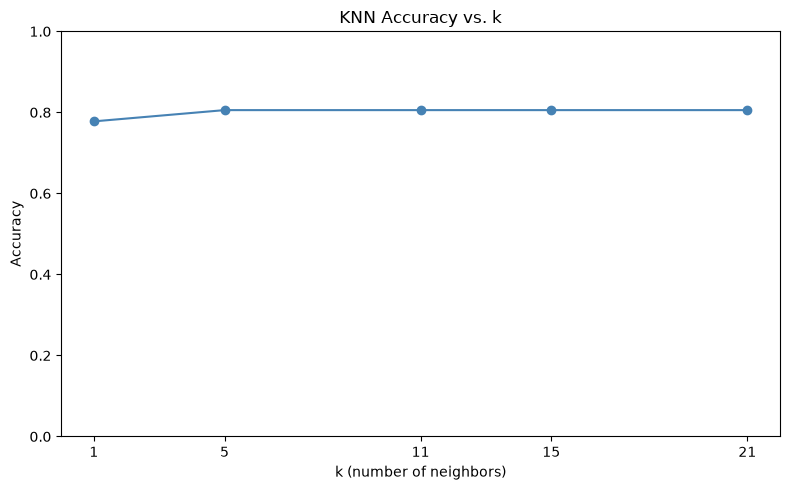

In [9]:
plt.figure()
plt.plot(knn_df["k"], knn_df["accuracy"], marker="o", color="steelblue")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs. k")
plt.ylim(0, 1)
plt.xticks(knn_df["k"])
plt.tight_layout()
plt.savefig("knn_accuracy_trend.png", dpi=150)
plt.show()


### 4.2 RNN Accuracy Trend

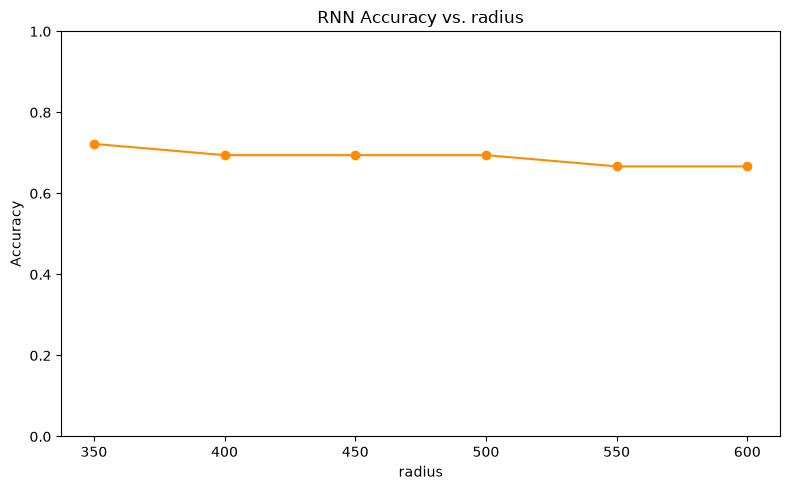

In [10]:
plt.figure()
plt.plot(rnn_df["radius"], rnn_df["accuracy"], marker="o", color="darkorange")
plt.xlabel("radius")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy vs. radius")
plt.ylim(0, 1)
plt.xticks(rnn_df["radius"])
plt.tight_layout()
plt.savefig("rnn_accuracy_trend.png", dpi=150)
plt.show()


### 4.3 Side-by-Side Comparison

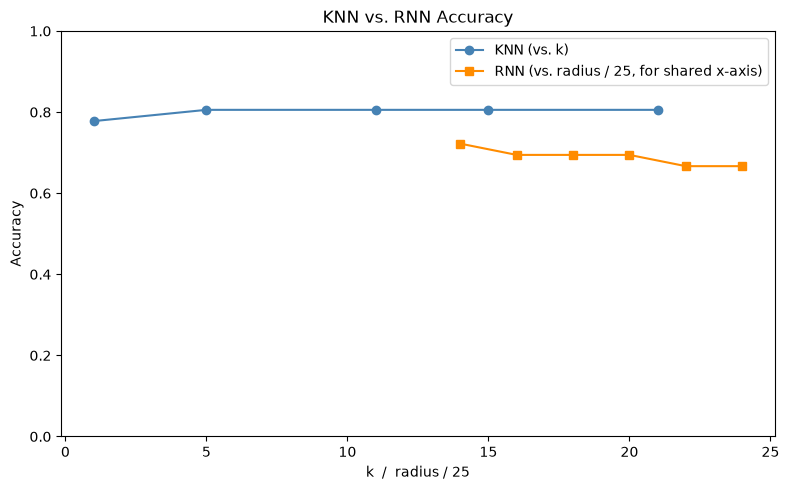

In [11]:
fig, ax = plt.subplots()
ax.plot(knn_df["k"], knn_df["accuracy"], marker="o", color="steelblue", label="KNN (vs. k)")
ax.plot(rnn_df["radius"] / 25, rnn_df["accuracy"], marker="s", color="darkorange",
        label="RNN (vs. radius / 25, for shared x-axis)")
ax.set_xlabel("k  /  radius / 25")
ax.set_ylabel("Accuracy")
ax.set_title("KNN vs. RNN Accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("knn_vs_rnn_comparison.png", dpi=150)
plt.show()


**Comparison and observations:**

- Best KNN accuracy reached about 0.81 (k=5 and above), while the best RNN accuracy was about
  0.72 (radius=350). On this dataset, KNN outperformed RNN at every setting tested.
- KNN accuracy rises sharply from k=1 to k=5 and then plateaus - a single neighbor is too
  sensitive to noise, but once enough neighbors vote together the class boundary estimate
  stabilizes, and larger k (up to 21) doesn't hurt here because the classes are still fairly
  well separated in feature space.
- RNN accuracy moves in the opposite direction: it's highest at the smallest radius tested
  (350) and steadily drops as the radius grows to 600. A larger radius pulls in points from
  neighboring classes (especially since `proline` and `magnesium` have wide ranges), diluting
  the majority vote with the wrong class.
- **When KNN vs. RNN might be preferable:** KNN is more robust here because it always uses a
  fixed number of neighbors, so it adapts automatically to how densely or sparsely points are
  packed in different regions of feature space. RNN depends entirely on picking a radius that
  matches the data's scale and density - too small and some points may have few or no
  neighbors, too large and it starts mixing in the wrong class, as seen above. RNN can still be
  useful when the notion of "close" has a real physical meaning (e.g. a fixed distance
  threshold matters more than a fixed neighbor count), but for a dataset like this one, with
  features on very different scales and no clean natural radius, KNN is the more reliable and
  easier to tune choice.


## Summary

This notebook loaded the Wine dataset, explored its features and class balance, split it 80/20
into training and test sets, and compared K-Nearest Neighbors against Radius Neighbors across a
range of hyperparameter values. KNN consistently outperformed RNN on this dataset and was less
sensitive to its hyperparameter choice. See `README.md` for a summary of the key takeaways and
the decisions made along the way.
